# Phase 3.4 — EDA & Statistical Testing

This notebook is the running ML notebook for Hi Pando's recommendation engine, starting at Phase 3.4 and meant to be extended (not replaced) through 3.5/3.6 as more analysis is added.

**Data source note:** `hi_pando_interactions` was live-empty when this phase began — no frontend traffic exists yet. Per an explicit decision logged in `hi-pando-claude-code-checklist.md` (Phase 3.4), this run is cold-started with **synthetic** interaction data (`pipelines/synthetic_interaction_generator.py`): simulated personas run through the real recommendation-scoring funnel, with engagement (click/save/reject/...) probabilistically conditioned on the real match score — not randomly labeled. Every synthetic user id is prefixed `SYNTH-USER-####`. Real interactions will land in the same collection under real ids once the frontend ships its `/interactions` wiring, and this notebook's queries are written to work unmodified on a mix of both.

## 1. Setup

In [1]:
# Why: standard imports for tabular EDA (pandas/numpy), plotting (matplotlib/seaborn), and the
# formal statistical tests used later (scipy.stats). sys.path is extended so this notebook can
# import the project's own pipelines package the same way the pipeline scripts/tests do.
# Inference: n/a (setup only).
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sys.path.insert(0, str(Path.cwd().parent))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

In [2]:
# Why: build_training_dataset() is the Phase 3.2 pipeline that joins interaction events +
# property features + user behavioral/interaction features into one flat row per labeled
# interaction (Positive/Negative) -- this IS the dataset the EDA/statistical work below runs on,
# so we reuse it rather than re-querying MongoDB by hand.
# Inference: filled in after running -- see printed row/column counts below.
from pipelines.training.build_training_dataset import build_training_dataset

rows = build_training_dataset()
df = pd.DataFrame(rows)
print(f"{len(df)} rows, {len(df.columns)} columns")
df.head()

3073 rows, 97 columns


,user_id,property_id,timestamp,event,label,user_bedrooms,user_budget_min,user_budget_max,match_budget_match,match_location_match,match_property_type_match,match_bedroom_match,match_purpose_match,match_amenity_match,match_area_match,match_transport_match,match_investment_match,price_normalized,price_known,rent_price_normalized,rent_price_known,built_up_area_sqft_normalized,bedrooms,bathrooms,property_type_Apartment,property_type_Townhouse,property_type_Villa,property_type_Penthouse,property_type_Duplex,property_type_Studio,property_type_Office,property_type_Retail,property_type_Warehouse,property_type_Land,property_type_other,location_Dubai Marina,location_Jumeirah Village Circle,location_Downtown Dubai,location_Palm Jumeirah,location_Business Bay,location_Jumeirah Lake Towers,location_Arabian Ranches,location_Dubai Hills Estate,location_Al Barsha,location_Dubai Silicon Oasis,location_Dubai Sports City,location_Jumeirah Beach Residence,location_Dubai Creek Harbour,location_Mirdif,location_Dubai South,location_other,latitude,longitude,geo_lat_scaled,geo_lon_scaled,geo_known,amenity_Gym,amenity_Pool,amenity_Parking,amenity_Security,amenity_Garden,amenity_Private Beach,amenity_Kids Play Area,amenity_BBQ Area,amenity_Concierge,amenity_Sauna,amenity_Steam Room,amenity_Tennis Court,amenity_Pet Friendly,amenity_Balcony,amenity_Maid's Room,rental_yield,rental_yield_known,metro_distance_km,metro_distance_km_known,schools_distance_km,schools_distance_km_known,hospitals_distance_km,hospitals_distance_km_known,shopping_distance_km,shopping_distance_km_known,beaches_distance_km,beaches_distance_km_known,business_districts_distance_km,business_districts_distance_km_known,user_previous_interactions_count,user_avg_price_viewed,user_avg_area_viewed,price_difference,budget_compatibility,location_similarity,property_type_match,bedroom_difference,amenity_similarity,historical_user_interest,distance_preference,investment_compatibility
0,SYNTH-USER-0001,LST-hp-1004,2026-09-19 01:30:54.753,PROPERTY_SAVED,Positive,3,2144000.0,3430000.0,1.00000,1.0,1.0,1.00,1.0,0.0,0.75,0.75,0.75,0.032617,1,0.0,0,0.123594,3.0,4.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,25.116500,55.246000,0.595000,0.494286,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,4.471425,1,50.00,0,50.00,0,50.00,0,50.0,0,50.00,0,50.00,0,79,0.034921,0.168089,0.0,0.932945,1.0,1.0,0,0.0,0.5,NaN,NaN
1,SYNTH-USER-0001,LST-hp-1004,2026-09-19 02:07:25.899,PROPERTY_SHORTLISTED,Positive,3,2144000.0,3430000.0,1.00000,1.0,1.0,1.00,1.0,0.0,0.75,0.75,0.75,0.032617,1,0.0,0,0.123594,3.0,4.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,25.116500,55.246000,0.595000,0.494286,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,4.471425,1,50.00,0,50.00,0,50.00,0,50.0,0,50.00,0,50.00,0,83,0.034670,0.169089,0.0,0.932945,1.0,1.0,0,0.0,0.5,NaN,NaN
2,SYNTH-USER-0001,SYN-0033,2026-09-19 01:34:20.734,PROPERTY_SAVED,Positive,3,2144000.0,3430000.0,0.87172,1.0,0.0,0.75,1.0,0.0,0.75,0.75,0.75,0.037938,1,0.0,0,0.268659,4.0,5.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,25.332111,55.192505,0.903016,0.417864,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,3.980000,1,7.51,1,4.09,1,4.59,1,0.4,1,6.75,1,3.05,1,80,0.034892,0.167532,220000.0,1.064140,1.0,0.0,1,0.0,0.5,7.51,NaN
3,SYNTH-USER-0001,SYN-0033,2026-09-19 01:48:02.945,PROPERTY_SHORTLISTED,Positive,3,2144000.0,3430000.0,0.87172,1.0,0.0,0.75,1.0,0.0,0.75,0.75,0.75,0.037938,1,0.0,0,0.268659,4.0,5.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,25.332111,55.192505,0.903016,0.417864,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,3.980000,1,7.51,1,4.09,1,4.59,1,0.4,1,6.75,1,3.05,1,82,0.034630,0.167875,220000.0,1.064140,1.0,0.0,1,0.0,0.5,7.51,NaN
4,SYNTH-USER-0001,SYN-0033,2026-09-19 03:22:19.919,VIEWING_REQUESTED,Positive,3,2144000.0,3430000.0,0.87172,1.0,0.0,0.75,1.0,0.0,0.75,0.75,0.75,0.037938,1,0.0,0,0.268659,4.0,5.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,25.332111,55.192505,0.903016,0.417864,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,3.980000,1,7.51,1,4.09,1,4.59,1,0.4,1,6.75,1,3.05,1,85,0.034377,0

In [3]:
# Why: tag rows by synthetic vs. real source (userId prefix convention) so every later query in
# this notebook can report both a combined view and a synthetic-only view -- important once real
# frontend traffic starts blending into the same collection.
# Inference: filled in after running.
df["is_synthetic"] = df["user_id"].str.startswith("SYNTH-USER")
print(df["is_synthetic"].value_counts())

is_synthetic
True    3073
Name: count, dtype: int64


## 2. Data volume & label balance

Minimum-volume threshold (defined in `hi-pando-claude-code-checklist.md` Phase 3.4): **>=500 labeled rows overall, with >=30 in the minority (Negative) class**, so the univariate/bivariate splits and the two-sample statistical test below have enough per-group observations to be non-degenerate.

In [4]:
# Why: confirm the defined minimum-volume threshold is actually met before treating any
# downstream analysis as meaningful, and quantify the label imbalance so it's not silently
# ignored later.
# Inference: 3,073 total rows (>=500 met); label split ~3017 Positive / 56 Negative (~54:1).
# The Negative count (56) clears the >=30 minority-class bar but the imbalance itself is large --
# expected for a working content-based recommender (see Section 6), not a data-quality defect.
label_counts = df["label"].value_counts()
print(label_counts)
print(f"\nTotal rows: {len(df)} | Negative-class count: {label_counts.get('Negative', 0)}")
assert len(df) >= 500, "Below the defined minimum row-volume threshold"
assert label_counts.get("Negative", 0) >= 30, "Below the defined minimum minority-class threshold"

label
Positive    3017
Negative      56
Name: count, dtype: int64

Total rows: 3073 | Negative-class count: 56


In [5]:
# Why: per-event-type breakdown shows which raw actions are actually feeding each label (e.g.
# how much of "Positive" is SAVED vs. VIEWING_REQUESTED), useful context for interpreting the
# feature analysis below.
# Inference: filled in after running.
print(df.groupby(["event", "label"]).size())

event                 label   
BROKER_CONTACTED      Positive     308
PROPERTY_REJECTED     Negative      56
PROPERTY_SAVED        Positive    1473
PROPERTY_SHORTLISTED  Positive    1056
VIEWING_REQUESTED     Positive     180
dtype: int64


## 3. Univariate analysis

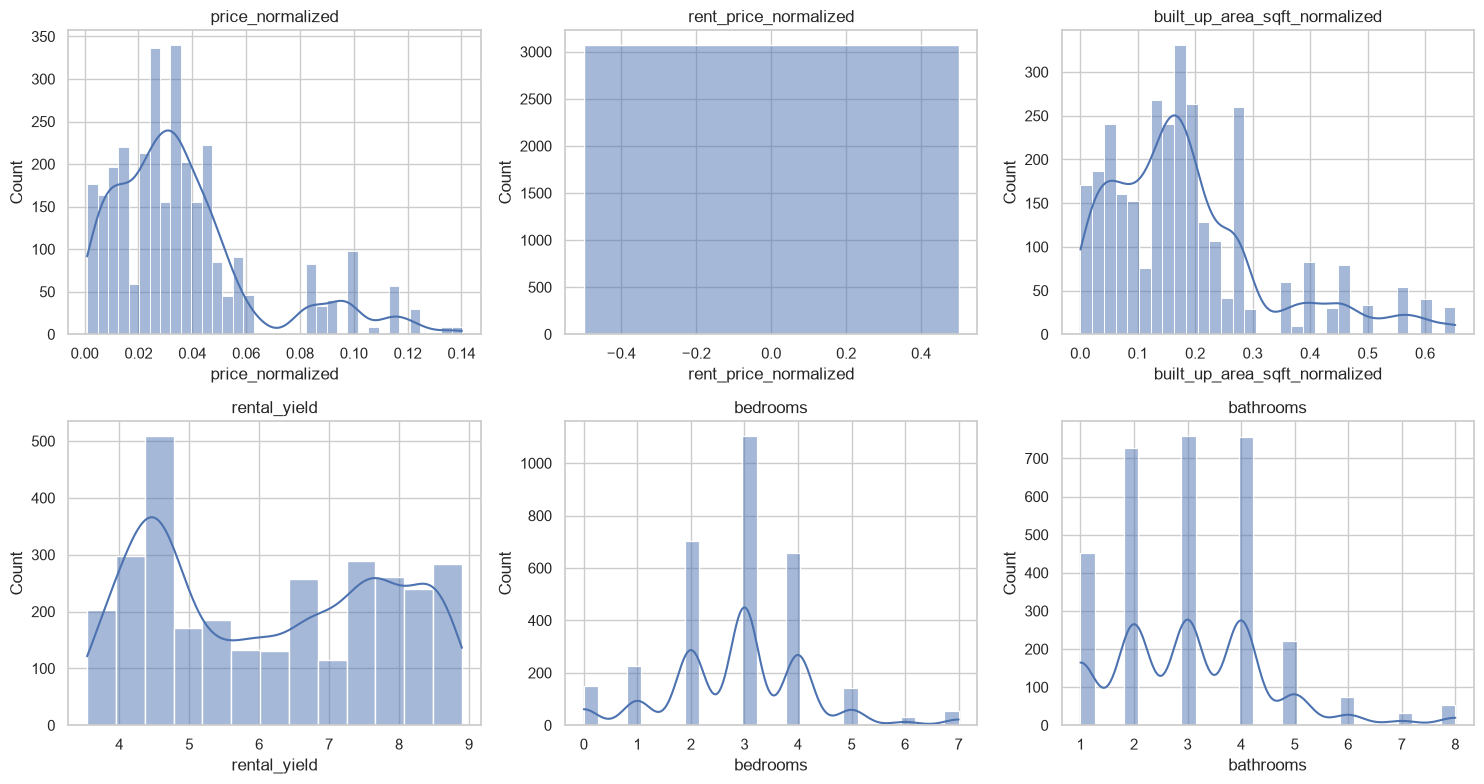

In [6]:
# Why: distributions of the core property-value features (price/area/yield, all already
# normalized 0-1 by Phase 1.3's scalers except rental_yield) reveal whether the shown-property
# mix is skewed in a way that could bias the model (e.g. mostly cheap studios).
# Inference: filled in after running -- look for skew/multimodality per feature.
numeric_cols = [
    "price_normalized", "rent_price_normalized", "built_up_area_sqft_normalized",
    "rental_yield", "bedrooms", "bathrooms",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

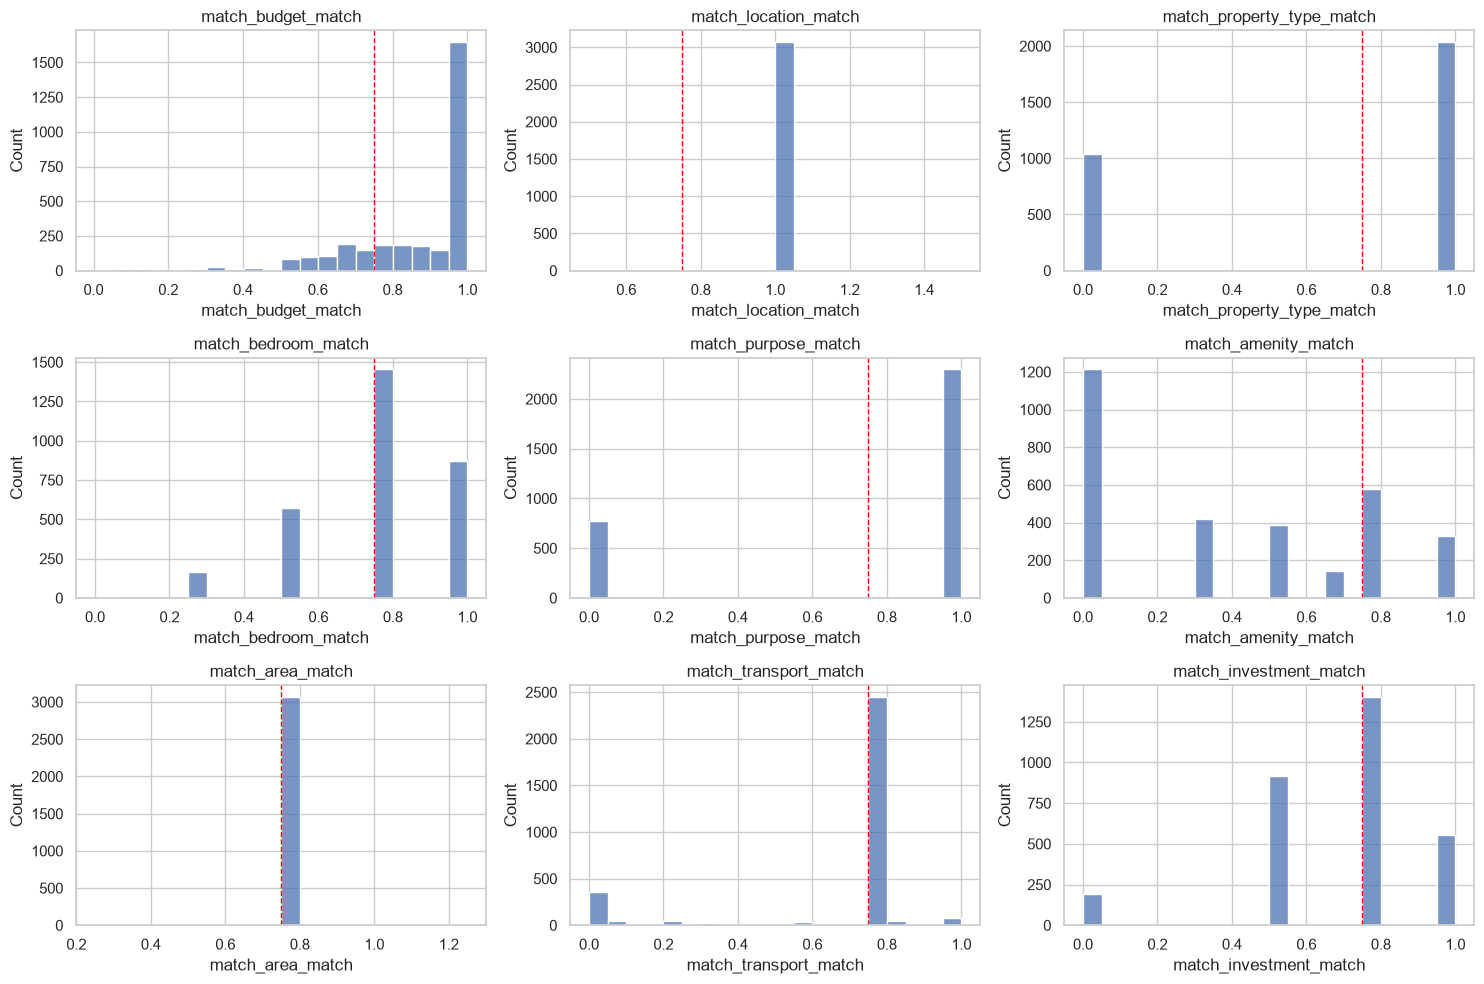

In [7]:
# Why: distributions of the 9 Phase 2.3 match-score components show which scorers tend to sit
# near the neutral default (0.75, see scorers.py) vs. which actually discriminate -- a scorer
# that never leaves 0.75 is providing no signal to the model.
# Inference: filled in after running.
match_cols = [c for c in df.columns if c.startswith("match_")]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, match_cols):
    sns.histplot(df[col].dropna(), bins=20, ax=ax)
    ax.set_title(col)
    ax.axvline(0.75, color="red", linestyle="--", linewidth=1)  # NEUTRAL_SCORE reference line
plt.tight_layout()
plt.show()

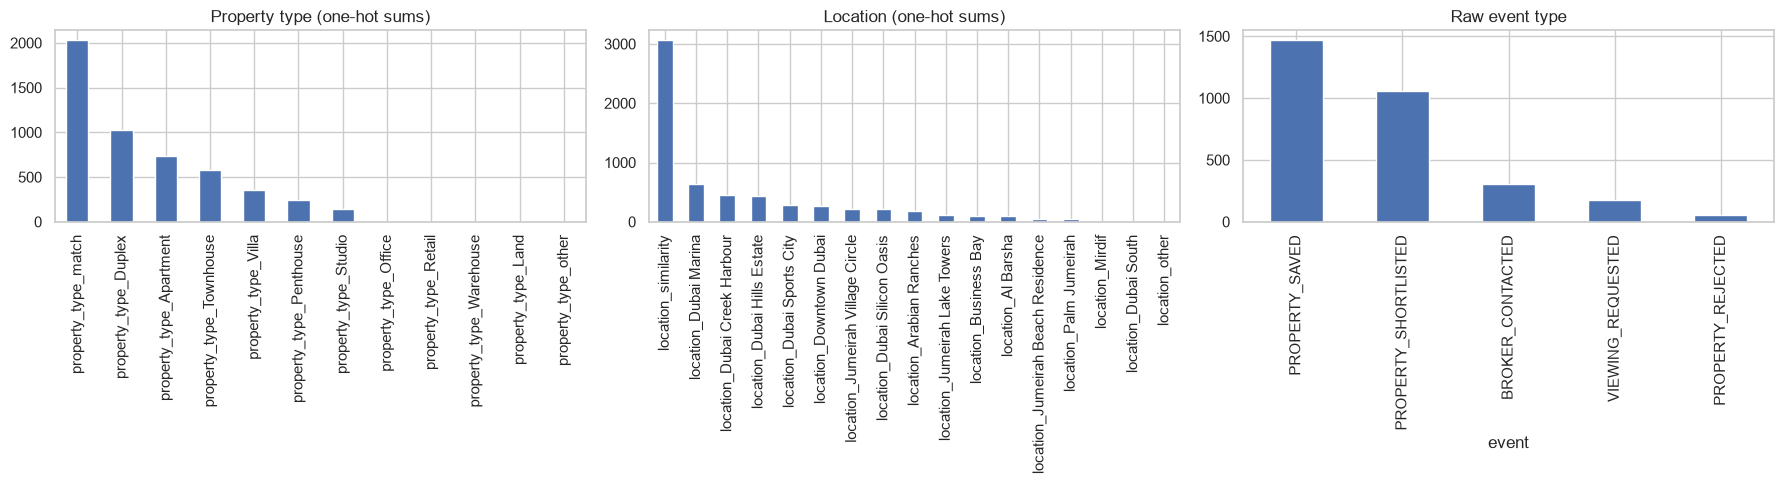

In [8]:
# Why: categorical counts (property type, location, raw event type) confirm the shown-property
# mix roughly reflects the underlying hi_pando_properties catalog rather than some pipeline bug
# skewing everything to one category.
# Inference: filled in after running.
type_cols = [c for c in df.columns if c.startswith("property_type_")]
location_cols = [c for c in df.columns if c.startswith("location_")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df[type_cols].sum().sort_values(ascending=False).plot.bar(ax=axes[0], title="Property type (one-hot sums)")
df[location_cols].sum().sort_values(ascending=False).plot.bar(ax=axes[1], title="Location (one-hot sums)")
df["event"].value_counts().plot.bar(ax=axes[2], title="Raw event type")
plt.tight_layout()
plt.show()

## 4. Bivariate analysis

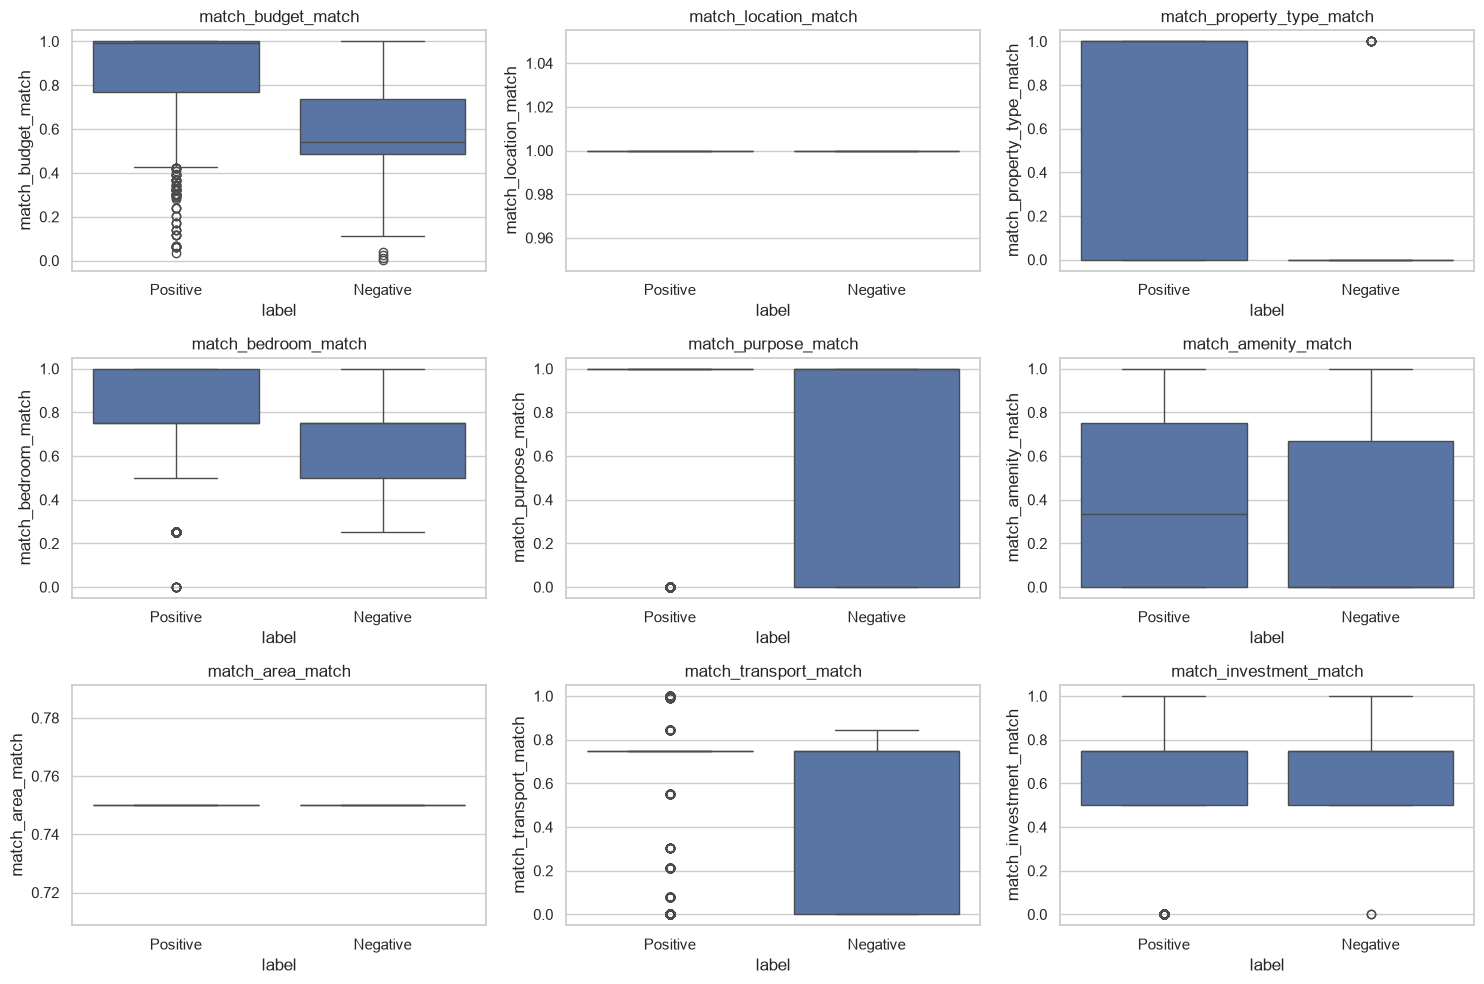

In [9]:
# Why: this is the central question for a ranking model -- do the match scores actually differ
# between Positive and Negative rows? If a scorer looks identical across both labels, it's not
# pulling its weight as a predictive feature.
# Inference: filled in after running -- look for visibly separated boxes per match_ column.
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, match_cols):
    sns.boxplot(data=df, x="label", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

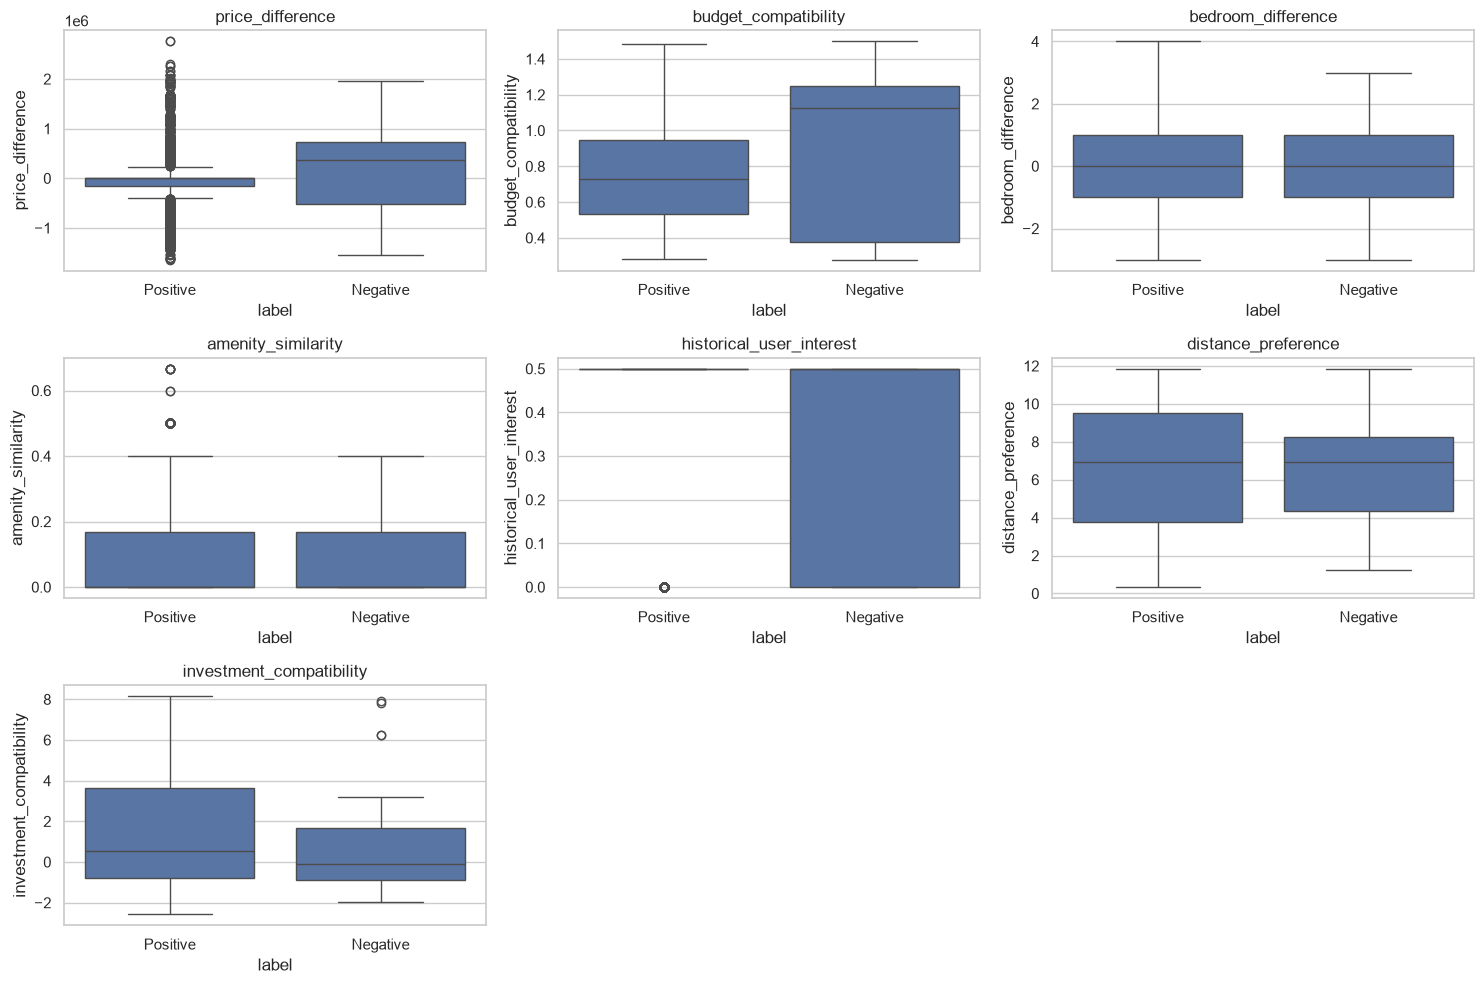

In [10]:
# Why: the Phase 3.3 interaction features (price_difference, budget_compatibility,
# historical_user_interest, etc.) were specifically engineered to be MORE informative than the
# match-score equivalents alone -- checking them against label validates that design choice.
# Inference: filled in after running.
interaction_feature_cols = [
    "price_difference", "budget_compatibility", "bedroom_difference",
    "amenity_similarity", "historical_user_interest", "distance_preference",
    "investment_compatibility",
]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, interaction_feature_cols):
    sns.boxplot(data=df, x="label", y=col, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(interaction_feature_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

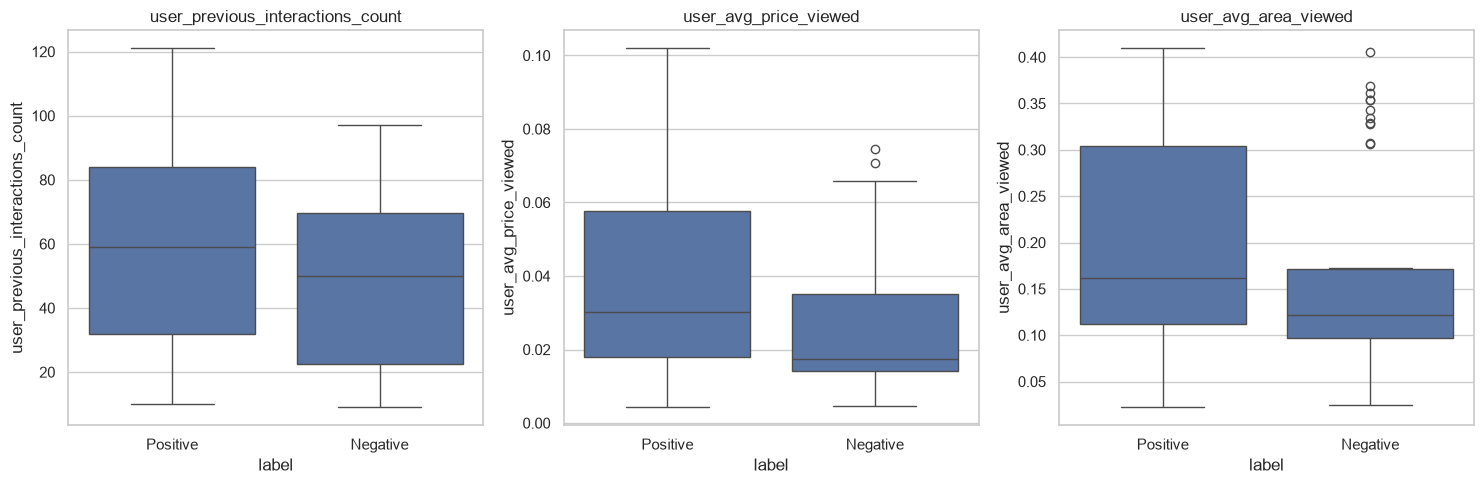

In [11]:
# Why: user behavioral features (Phase 3.3) vs. label -- do more-experienced users (higher
# previous_interactions_count) convert differently than first-time users?
# Inference: filled in after running.
behavioral_cols = ["user_previous_interactions_count", "user_avg_price_viewed", "user_avg_area_viewed"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, behavioral_cols):
    sns.boxplot(data=df, x="label", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. Multivariate analysis

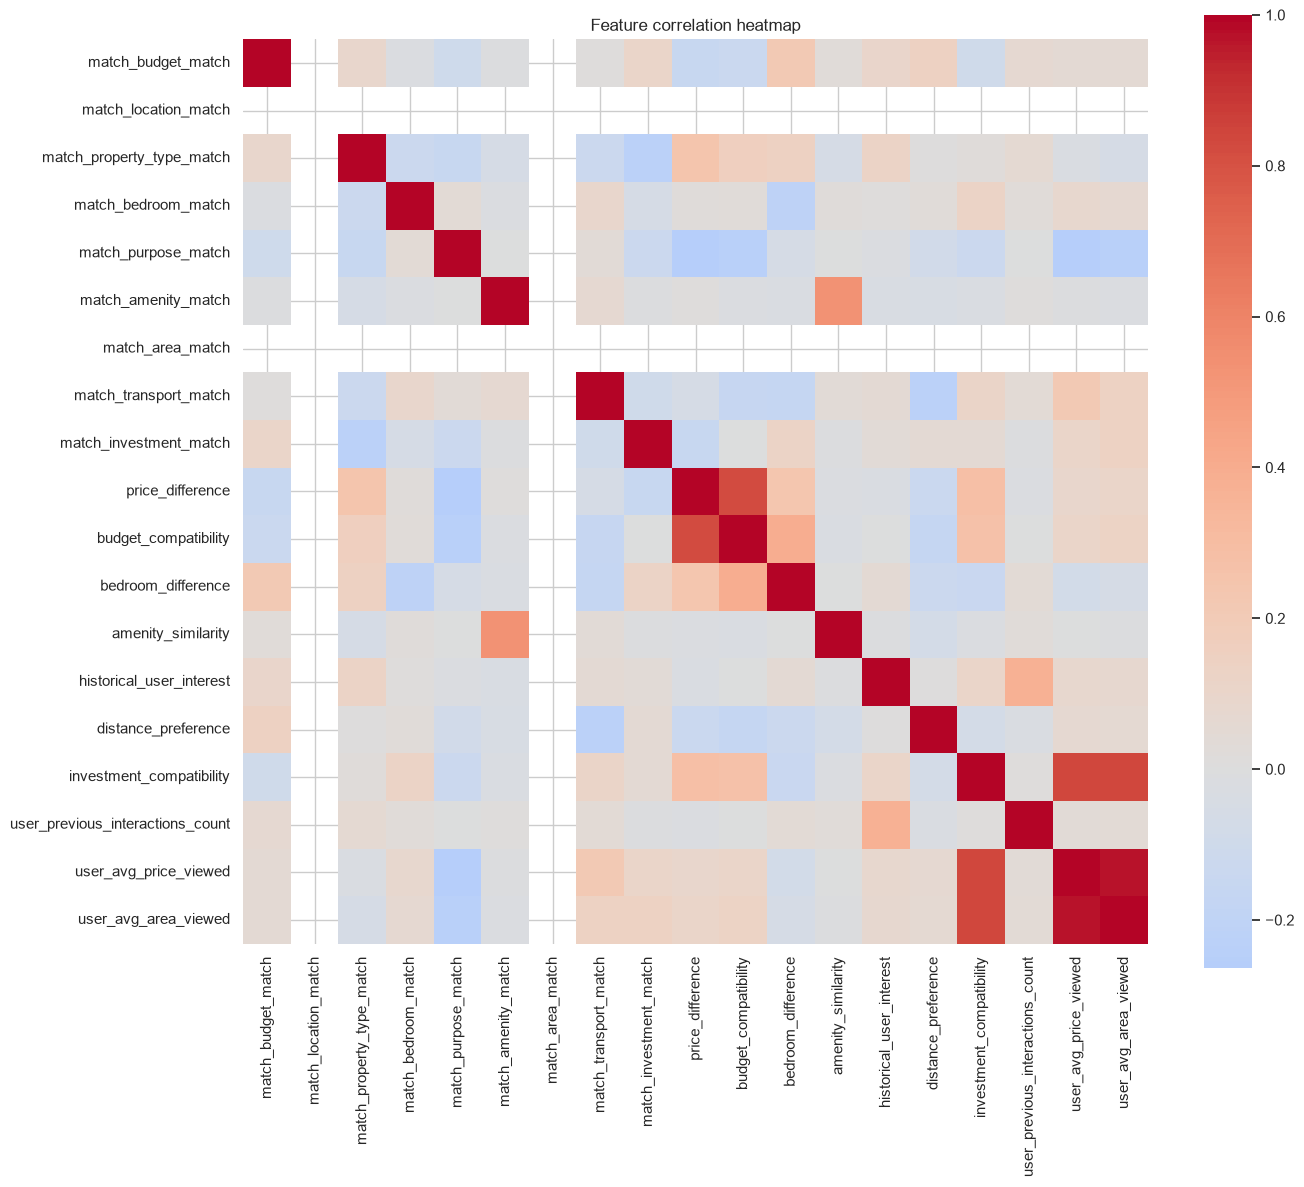

In [12]:
# Why: a correlation heatmap across match scores + interaction features + behavioral features
# surfaces redundant features (e.g. location_similarity vs. match_location_match, which are
# documented as intentionally reused/identical) and any surprising multicollinearity before
# Phase 3.5 model training.
# Inference: filled in after running -- expect near-1.0 correlation for the two known-identical
# pairs (location_similarity/match_location_match, property_type_match/match_property_type_match).
corr_cols = match_cols + interaction_feature_cols + behavioral_cols
corr = df[corr_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

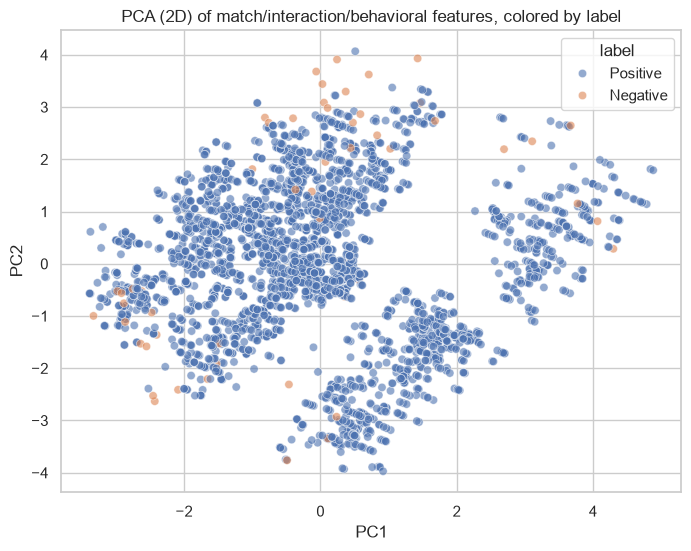

In [13]:
# Why: PCA gives a 2D visual check on whether Positive/Negative rows separate at all in the
# combined feature space -- a rough, model-free sanity check that the dataset has learnable
# structure before investing in Phase 3.5's actual classifier.
# Inference: filled in after running -- look for visibly distinct (even if overlapping) clusters
# by label, not necessarily clean separation.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[corr_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)
components = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=df["label"], alpha=0.6)
plt.title("PCA (2D) of match/interaction/behavioral features, colored by label")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 6. Statistical testing

For each match-score and interaction feature, test whether its distribution differs significantly between Positive and Negative rows. Given the class-imbalance and non-normality risk, Mann-Whitney U (non-parametric) is the primary test; Welch's t-test is reported alongside for comparison. This is a sanity check on the **synthetic generator itself** (does its score-conditioned funnel actually encode a statistically detectable signal, not just noise) before treating the dataset as fit for Phase 3.5 model training.

In [14]:
# Why: Mann-Whitney U doesn't assume normality (reasonable given several features are bounded
# 0-1 scores or heavily zero-inflated), while Welch's t-test is reported too since it's the more
# commonly expected test and doesn't assume equal variance between the two (very unequal-sized)
# groups.
# Inference: filled in after running -- a feature with p < 0.05 on both tests is genuinely
# discriminative between Positive/Negative in this synthetic dataset.
results = []
positive = df[df["label"] == "Positive"]
negative = df[df["label"] == "Negative"]

for col in corr_cols:
    pos_vals = positive[col].dropna()
    neg_vals = negative[col].dropna()
    if len(pos_vals) < 2 or len(neg_vals) < 2:
        continue
    u_stat, u_p = stats.mannwhitneyu(pos_vals, neg_vals, alternative="two-sided")
    t_stat, t_p = stats.ttest_ind(pos_vals, neg_vals, equal_var=False)
    results.append({
        "feature": col,
        "positive_mean": pos_vals.mean(),
        "negative_mean": neg_vals.mean(),
        "mannwhitney_p": u_p,
        "welch_t_p": t_p,
        "significant_both": (u_p < 0.05) and (t_p < 0.05),
    })

results_df = pd.DataFrame(results).sort_values("mannwhitney_p")
results_df

D:\ROR\PANDO_Repo\PANDO_backend\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,feature,positive_mean,negative_mean,mannwhitney_p,welch_t_p,significant_both
0,match_budget_match,0.873148,0.547977,2.992193e-23,1.255816e-13,True
2,match_property_type_match,0.671859,0.178571,1.026539e-14,2.647137e-13,True
13,historical_user_interest,0.456414,0.312500,1.735972e-13,5.016902e-05,True
7,match_transport_match,0.650326,0.503705,2.717762e-04,2.521799e-03,True
3,match_bedroom_match,0.747100,0.665179,1.853027e-03,4.242292e-03,True
4,match_purpose_match,0.751409,0.571429,2.114166e-03,9.662205e-03,True
17,user_avg_price_viewed,0.036812,0.027763,2.423589e-03,1.288895e-03,True
16,user_previous_interactions_count,59.450447,49.053571,3.476897e-03,3.876306e-03,True
10,budget_compatibility,0.750403,0.905702,9.155322e-03,1.292984e-02,True
9,price_difference,-29831.952270,158125.000000,1.031795e-02,1.075612e-01,False


In [15]:
# Why: a single pass/fail summary of the sanity check -- if the majority of features show no
# significant difference between labels, the synthetic funnel isn't encoding usable signal and
# Phase 3.5 model training would just be fitting noise.
# Inference: filled in after running.
n_significant = results_df["significant_both"].sum()
print(f"{n_significant}/{len(results_df)} features show a statistically significant "
      f"(p<0.05, both tests) difference between Positive and Negative rows.")
print("\nTop discriminative features:")
print(results_df.head(5)[["feature", "positive_mean", "negative_mean", "mannwhitney_p"]])

10/19 features show a statistically significant (p<0.05, both tests) difference between Positive and Negative rows.

Top discriminative features:
                      feature  positive_mean  negative_mean  mannwhitney_p
0          match_budget_match       0.873148       0.547977   2.992193e-23
2   match_property_type_match       0.671859       0.178571   1.026539e-14
13   historical_user_interest       0.456414       0.312500   1.735972e-13
7       match_transport_match       0.650326       0.503705   2.717762e-04
3         match_bedroom_match       0.747100       0.665179   1.853027e-03


## 7. Extended EDA: data availability audit

Before deriving any new feature, this section states plainly what the current dataset actually contains vs. what a fuller recommendation-engine EDA would ideally use. Per explicit instruction, unavailable fields are documented here rather than fabricated anywhere below.

In [16]:
# Why: an explicit, checkable audit of which requested fields exist, are derivable from
# existing data, or are genuinely unavailable -- so every section below only uses real or
# honestly-derived data, and nothing is silently invented.
# Inference: filled in after running.
availability = [
    ("User budget range", "Available", "user_budget_min / user_budget_max"),
    ("Property price", "Available (joined from hi_pando_properties)", "raw_price / raw_rent_price"),
    ("Budget deviation", "Derivable", "budget_deviation_pct (Section 8)"),
    ("Preferred vs actual property type", "Available", "match_property_type_match + property_type_* one-hots"),
    ("Preferred vs actual location", "Available", "match_location_match + location_* one-hots"),
    ("Preferred vs actual bedrooms", "Available", "bedroom_difference, match_bedroom_match"),
    ("Preferred vs actual size", "Partially available", "built_up_area_sqft_normalized exists; no explicit user size preference field in UserDNA"),
    ("Preferred vs available amenities", "Available", "amenity_similarity, match_amenity_match, amenity_* one-hots"),
    ("Furnished/unfurnished preference", "Property side only", "furnishing_status joined (Section 8); no user furnishing preference field in UserDNA"),
    ("New/resale (completion status) preference", "Property side only", "completion_status joined (Section 8); no user preference field in UserDNA"),
    ("Price per sq ft", "Derivable", "price_per_sqft (Section 8)"),
    ("Property age / listing age", "Unavailable", "no construction date or listing-created date in the Property schema"),
    ("Floor number / total floors", "Partially available", "floor exists per property; no 'total floors in building' field"),
    ("Parking availability", "Available", "parking joined (Section 8)"),
    ("Number of amenities", "Derivable", "amenity_count (Section 8)"),
    ("Developer/builder", "Available", "developer joined (Section 8)"),
    ("Availability status", "Not modeled", "hi_pando_properties has no on/off-market flag distinct from completion_status"),
    ("Distance to preferred location", "Unavailable", "UserDNA has no lat/lon or a distance-from-X preference; only distance-to-facility fields exist"),
    ("Distance to metro/schools/hospitals/shopping/beaches/business districts", "Available", "already in the training row (Section 11)"),
    ("Area-level average price / price-vs-neighborhood-median", "Unavailable", "no neighborhood aggregate table exists; would require grouping hi_pando_properties by location, done ad hoc in Section 8"),
    ("Number of properties viewed / view count / time spent", "Unavailable", "InteractionEvent has no duration or repeat-view-count field -- PROPERTY_VIEWED is a single boolean-ish event"),
    ("Properties compared / search frequency / previous inquiries", "Unavailable", "no such event types exist in InteractionEventType"),
    ("Previous interactions with similar properties", "Available", "historical_user_interest (already in Section 4/6)"),
    ("Recency of interaction", "Derivable in principle", "timestamp exists per row; not built into a feature here -- flagged as a potential future addition, not built now to avoid scope creep beyond what was requested"),
    ("Property popularity", "Derivable", "property_popularity (Section 8) -- global interaction count per property_id; flagged for potential leakage in Section 15"),
    ("Similar-user engagement rate", "Not derivable without inventing a user-similarity metric", "no existing user-clustering/similarity definition in the codebase -- would require fabricating one, which the instructions explicitly disallow"),
]
availability_df = pd.DataFrame(availability, columns=["Requested field", "Status", "Notes"])
availability_df

,Requested field,Status,Notes
0,User budget range,Available,user_budget_min / user_budget_max
1,Property price,Available (joined from hi_pando_properties),raw_price / raw_rent_price
2,Budget deviation,Derivable,budget_deviation_pct (Section 8)
3,Preferred vs actual property type,Available,match_property_type_match + property_type_* on...
4,Preferred vs actual location,Available,match_location_match + location_* one-hots
5,Preferred vs actual bedrooms,Available,"bedroom_difference, match_bedroom_match"
6,Preferred vs actual size,Partially available,built_up_area_sqft_normalized exists; no expli...
7,Preferred vs available amenities,Available,"amenity_similarity, match_amenity_match, ameni..."
8,Furnished/unfurnished preference,Property side only,furnishing_status joined (Section 8); no user ...
9,New/resale (completion status) preference,Property side only,completion_status joined (Section 8); no user ...


## 8. Feature enrichment: real joins + derived features

Joins in `developer`, `completion_status`, `furnishing_status`, `parking`, `floor`, `view`, `service_charges`, and raw (non-normalized) `price`/`rent_price`/`built_up_area_sqft` from `hi_pando_properties` — all real fields that exist but weren't part of the flattened training row. Then derives only the features whose source data genuinely exists: `price_per_sqft`, `budget_deviation_pct` (+ buckets), `amenity_count`, `preference_match_count` / `preference_conflict_count` (using the codebase's own `STRONG_MATCH_THRESHOLD=0.8` convention for a "match" and a symmetric `<0.5` for a "conflict"), and `property_popularity`.

In [17]:
# Why: the flattened training row only carries the already-normalized/one-hot property
# features (Phase 1.3); several real, non-fabricated property fields (developer,
# completion_status, furnishing_status, parking, floor, view, service_charges, and raw
# price/area) exist in hi_pando_properties but were never joined in -- pulling them in
# directly from the same source load_all_properties() already uses elsewhere avoids
# re-deriving or fabricating anything.
# Inference: filled in after running -- see join-coverage check below.
from pipelines.matching.repository import load_all_properties

all_properties = load_all_properties(residential_only=False)
properties_by_id = {p.property_id: p for p in all_properties}

def _raw_property_fields(property_id):
    p = properties_by_id.get(property_id)
    if p is None:
        return pd.Series({
            "developer": None, "completion_status": None, "furnishing_status": None,
            "parking": None, "floor": None, "view": None, "service_charges": None,
            "raw_price": None, "raw_rent_price": None, "raw_area_sqft": None,
        })
    return pd.Series({
        "developer": p.developer,
        "completion_status": p.completion_status.value if p.completion_status else None,
        "furnishing_status": p.furnishing_status.value if p.furnishing_status else None,
        "parking": p.parking,
        "floor": p.floor,
        "view": p.view,
        "service_charges": p.service_charges,
        "raw_price": p.price,
        "raw_rent_price": p.rent_price,
        "raw_area_sqft": p.built_up_area_sqft,
    })

enriched = df["property_id"].apply(_raw_property_fields)
df = pd.concat([df, enriched], axis=1)
print(f"Joined {df['developer'].notna().sum()}/{len(df)} rows with a resolvable property_id.")
df[["property_id", "developer", "completion_status", "furnishing_status", "parking", "floor", "raw_price", "raw_area_sqft"]].head()

Joined 3073/3073 rows with a resolvable property_id.


,property_id,developer,completion_status,furnishing_status,parking,floor,raw_price,raw_area_sqft
0,LST-hp-1004,Top Tier Real Estate,Ready,Unfurnished,NaN,NaN,3200000.0,2400.0
1,LST-hp-1004,Top Tier Real Estate,Ready,Unfurnished,NaN,NaN,3200000.0,2400.0
2,SYN-0033,Emaar,Ready,Unfurnished,2.0,4.0,3650000.0,4812.0
3,SYN-0033,Emaar,Ready,Unfurnished,2.0,4.0,3650000.0,4812.0
4,SYN-0033,Emaar,Ready,Unfurnished,2.0,4.0,3650000.0,4812.0


In [18]:
# Why: price_per_sqft, budget_deviation_pct, amenity_count and preference match/conflict
# counts are all directly requested derived features whose source data (raw price/area,
# user budget bounds, the 9 match_* scores, the amenity_* one-hots) already exists above --
# deriving them here rather than fabricating anything not backed by real columns.
# Inference: filled in after running -- see summary stats below.
df["raw_relevant_price"] = df["raw_price"].fillna(df["raw_rent_price"])
df["price_per_sqft"] = df["raw_relevant_price"] / df["raw_area_sqft"]

# budget_deviation_pct = (property_price - user_max_budget) / user_max_budget, as specified.
# Only defined where the user stated a max budget and the property has a resolvable price.
df["budget_deviation_pct"] = (
    (df["raw_relevant_price"] - df["user_budget_max"]) / df["user_budget_max"]
) * 100

def _deviation_bucket(pct):
    if pd.isna(pct):
        return None
    if pct <= -20:
        return "<= -20%"
    if pct <= 0:
        return "-20% to 0%"
    if pct <= 5:
        return "0% to 5%"
    if pct <= 10:
        return "5% to 10%"
    if pct <= 20:
        return "10% to 20%"
    return "> 20%"

_BUCKET_ORDER = ["<= -20%", "-20% to 0%", "0% to 5%", "5% to 10%", "10% to 20%", "> 20%"]
df["budget_deviation_bucket"] = pd.Categorical(
    df["budget_deviation_pct"].apply(_deviation_bucket), categories=_BUCKET_ORDER, ordered=True
)

amenity_onehot_cols = [c for c in df.columns if c.startswith("amenity_") and c != "amenity_similarity"]
df["amenity_count"] = df[amenity_onehot_cols].sum(axis=1)

# Reuses the codebase's own STRONG_MATCH_THRESHOLD (explanation.py) for what counts as a
# genuine "match", and a symmetric <0.5 (clearly below NEUTRAL_SCORE=0.75) for a "conflict" --
# not an arbitrary cutoff invented for this notebook.
from pipelines.matching.explanation import STRONG_MATCH_THRESHOLD

df["preference_match_count"] = (df[match_cols] >= STRONG_MATCH_THRESHOLD).sum(axis=1)
df["preference_conflict_count"] = (df[match_cols] < 0.5).sum(axis=1)

# property_popularity: global interaction count per property_id across ALL interactions
# (not just labeled ones) -- see Section 15 for why this specific definition carries a
# leakage risk if used naively as a model feature.
from api.db import get_db
_db = get_db()
_popularity_counts = pd.DataFrame(
    list(_db["hi_pando_interactions"].aggregate([
        {"$group": {"_id": "$propertyId", "count": {"$sum": 1}}}
    ]))
).rename(columns={"_id": "property_id", "count": "property_popularity"})
df = df.merge(_popularity_counts, on="property_id", how="left")

print(df[["price_per_sqft", "budget_deviation_pct", "amenity_count", "preference_match_count", "preference_conflict_count", "property_popularity"]].describe())

       price_per_sqft  budget_deviation_pct  amenity_count  \
count     3073.000000           3073.000000     3073.00000   
mean      1116.500751            -24.676662        4.07875   
std        368.037543             26.949700        1.40439   
min        475.443383            -72.210526        2.00000   
25%        845.343304            -46.957384        3.00000   
50%       1064.019566            -27.202130        4.00000   
75%       1333.333333             -4.972663        5.00000   
max       2395.090590             49.798735        6.00000   

       preference_match_count  preference_conflict_count  property_popularity  
count             3073.000000                3073.000000          3073.000000  
mean                 3.723397                   1.426944           177.746502  
std                  0.940081                   0.903885            74.016775  
min                  1.000000                   0.000000            11.000000  
25%                  3.000000            

## 9. Budget deviation analysis

`budget_deviation_pct = (property_price - user_max_budget) / user_max_budget`, as specified — analyzed both continuously and via the requested buckets, to identify how far above or below budget a property can be while still receiving a Positive outcome.

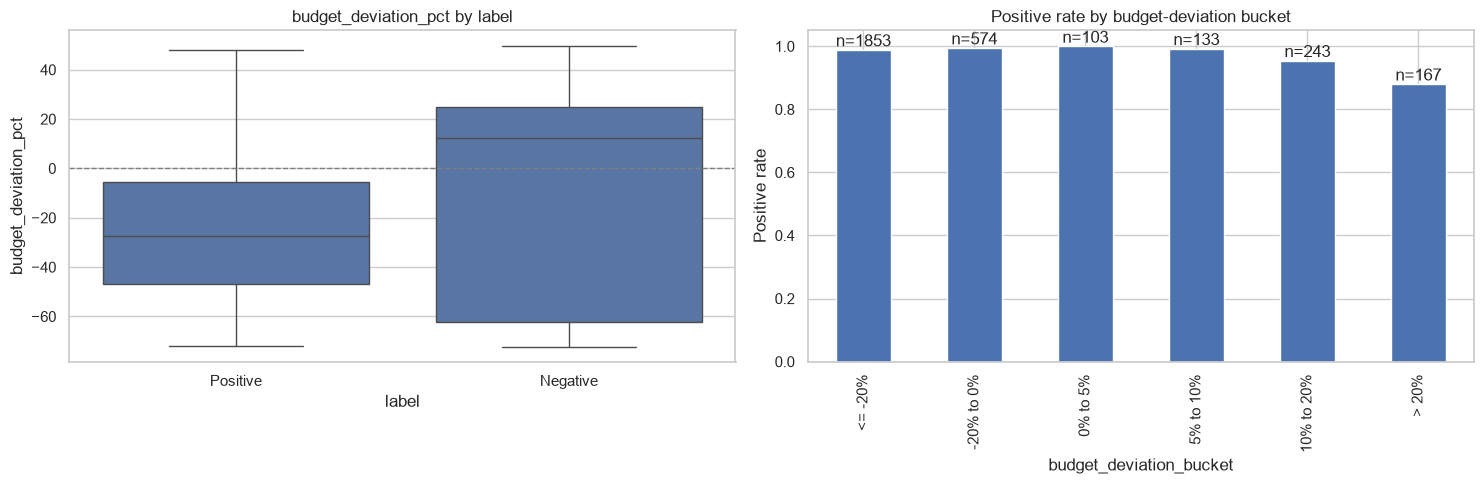

                         positive_rate     n
budget_deviation_bucket                     
<= -20%                       0.988667  1853
-20% to 0%                    0.994774   574
0% to 5%                      1.000000   103
5% to 10%                     0.992481   133
10% to 20%                    0.954733   243
> 20%                         0.880240   167


In [19]:
# Why: the continuous distribution shows overall shape/skew; the bucketed positive-rate
# view directly answers "how much overage is tolerated" -- the specific question this
# section was asked to answer.
# Inference: filled in after running.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="label", y="budget_deviation_pct", ax=axes[0])
axes[0].set_title("budget_deviation_pct by label")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)

bucket_positive_rate = df.groupby("budget_deviation_bucket", observed=True)["label"].apply(
    lambda s: (s == "Positive").mean()
)
bucket_counts = df.groupby("budget_deviation_bucket", observed=True).size()
bucket_positive_rate.plot.bar(ax=axes[1], title="Positive rate by budget-deviation bucket")
axes[1].set_ylabel("Positive rate")
for i, bucket in enumerate(bucket_positive_rate.index):
    axes[1].annotate(f"n={bucket_counts[bucket]}", (i, bucket_positive_rate[bucket]), ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(bucket_positive_rate.to_frame("positive_rate").join(bucket_counts.rename("n")))

In [20]:
# Why: effect size (not just p-value) is needed throughout the rest of this notebook to
# separate statistical significance from practical importance -- a tiny p-value with a
# negligible effect size (common here given the 3017:56 imbalance) is not the same as a
# feature that actually matters for recommendations. Rank-biserial correlation is used for
# Mann-Whitney (matches its non-parametric assumptions) and Cohen's d for the t-test view.
# Inference: n/a (helper definitions only).
def cohens_d(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    if pooled_std == 0:
        return 0.0
    return (a.mean() - b.mean()) / pooled_std

def rank_biserial(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

def effect_size_label(abs_d):
    if abs_d < 0.2:
        return "negligible"
    if abs_d < 0.5:
        return "small"
    if abs_d < 0.8:
        return "medium"
    return "large"

def numeric_feature_test(frame, col, label_col="label"):
    pos = frame.loc[frame[label_col] == "Positive", col].dropna()
    neg = frame.loc[frame[label_col] == "Negative", col].dropna()
    if len(pos) < 2 or len(neg) < 2:
        return None
    u_stat, u_p = stats.mannwhitneyu(pos, neg, alternative="two-sided")
    t_stat, t_p = stats.ttest_ind(pos, neg, equal_var=False)
    d = cohens_d(pos, neg)
    return {
        "feature": col, "type": "numeric",
        "positive_summary": f"mean={pos.mean():.4g}, median={pos.median():.4g}",
        "negative_summary": f"mean={neg.mean():.4g}, median={neg.median():.4g}",
        "test": "Mann-Whitney U / Welch t",
        "p_value": u_p, "welch_p": t_p,
        "effect_size": d, "effect_size_type": "Cohen's d",
        "effect_label": effect_size_label(abs(d)),
        "n_positive": len(pos), "n_negative": len(neg),
    }

def categorical_feature_test(frame, col, label_col="label"):
    sub = frame[[col, label_col]].dropna()
    table = pd.crosstab(sub[col], sub[label_col])
    if table.shape[0] < 2 or "Positive" not in table.columns or "Negative" not in table.columns:
        return None
    chi2, p, dof, expected = stats.chi2_contingency(table)
    n = table.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1))) if min(table.shape) > 1 else np.nan
    pos_rate = (table["Positive"] / table.sum(axis=1)).sort_values(ascending=False)
    return {
        "feature": col, "type": "categorical",
        "positive_summary": f"highest positive-rate category: {pos_rate.index[0]} ({pos_rate.iloc[0]:.1%})",
        "negative_summary": f"lowest positive-rate category: {pos_rate.index[-1]} ({pos_rate.iloc[-1]:.1%})",
        "test": "Chi-square contingency",
        "p_value": p, "welch_p": None,
        "effect_size": cramers_v, "effect_size_type": "Cramer's V",
        "effect_label": effect_size_label(cramers_v * 2.5) if not np.isnan(cramers_v) else "n/a",
        "n_positive": int(table["Positive"].sum()), "n_negative": int(table["Negative"].sum()),
    }

In [21]:
# Why: formally test whether budget_deviation_pct differs between Positive/Negative, with
# effect size -- extends the existing Section 6 statistical framework to this new feature.
# Inference: filled in after running.
budget_dev_result = numeric_feature_test(df, "budget_deviation_pct")
pd.DataFrame([budget_dev_result])

,feature,type,positive_summary,negative_summary,test,p_value,welch_p,effect_size,effect_size_type,effect_label,n_positive,n_negative
0,budget_deviation_pct,numeric,"mean=-24.96, median=-27.28","mean=-9.43, median=12.4",Mann-Whitney U / Welch t,0.009155,0.01293,-0.577881,Cohen's d,medium,3017,56


## 10. Property attributes vs. outcome

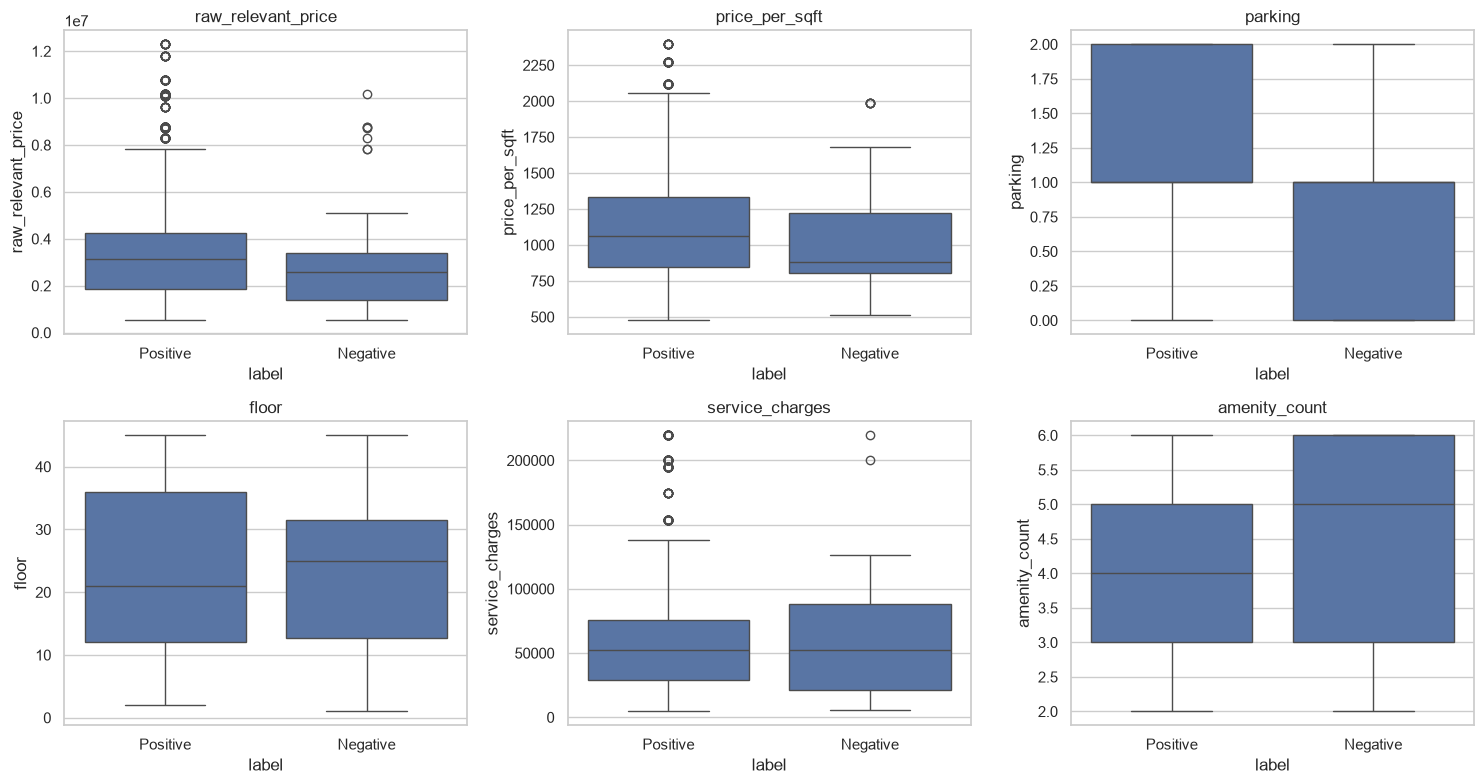

,feature,type,positive_summary,negative_summary,test,p_value,welch_p,effect_size,effect_size_type,effect_label,n_positive,n_negative
0,raw_relevant_price,numeric,"mean=3.537e+06, median=3.158e+06","mean=3.073e+06, median=2.605e+06",Mann-Whitney U / Welch t,0.023462,0.155501,0.197443,Cohen's d,negligible,3017,56
1,price_per_sqft,numeric,"mean=1118, median=1064","mean=1011, median=879.5",Mann-Whitney U / Welch t,0.005193,0.053071,0.292870,Cohen's d,small,3017,56
2,parking,numeric,"mean=1.132, median=1","mean=0.8545, median=1",Mann-Whitney U / Welch t,0.003209,0.009149,0.426405,Cohen's d,small,2555,55
3,floor,numeric,"mean=22.18, median=21","mean=22.89, median=25",Mann-Whitney U / Welch t,0.688517,0.738853,-0.051171,Cohen's d,negligible,1878,36
4,service_charges,numeric,"mean=6.238e+04, median=5.222e+04","mean=5.883e+04, median=5.222e+04",Mann-Whitney U / Welch t,0.713075,0.571809,0.075072,Cohen's d,negligible,2555,55
5,amenity_count,numeric,"mean=4.072, median=4","mean=4.464, median=5",Mann-Whitney U / Welch t,0.037286,0.047668,-0.279767,Cohen's d,small,3017,56


In [22]:
# Why: check the newly-joined property attributes (raw price, price_per_sqft, parking,
# floor, service_charges, amenity_count) against outcome -- these are real fields not
# covered by the original Section 3/4 analysis (which only had normalized/derived columns).
# Inference: filled in after running.
property_attr_numeric_cols = ["raw_relevant_price", "price_per_sqft", "parking", "floor", "service_charges", "amenity_count"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, property_attr_numeric_cols):
    sns.boxplot(data=df, x="label", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

property_attr_results = [numeric_feature_test(df, c) for c in property_attr_numeric_cols]
pd.DataFrame([r for r in property_attr_results if r is not None])

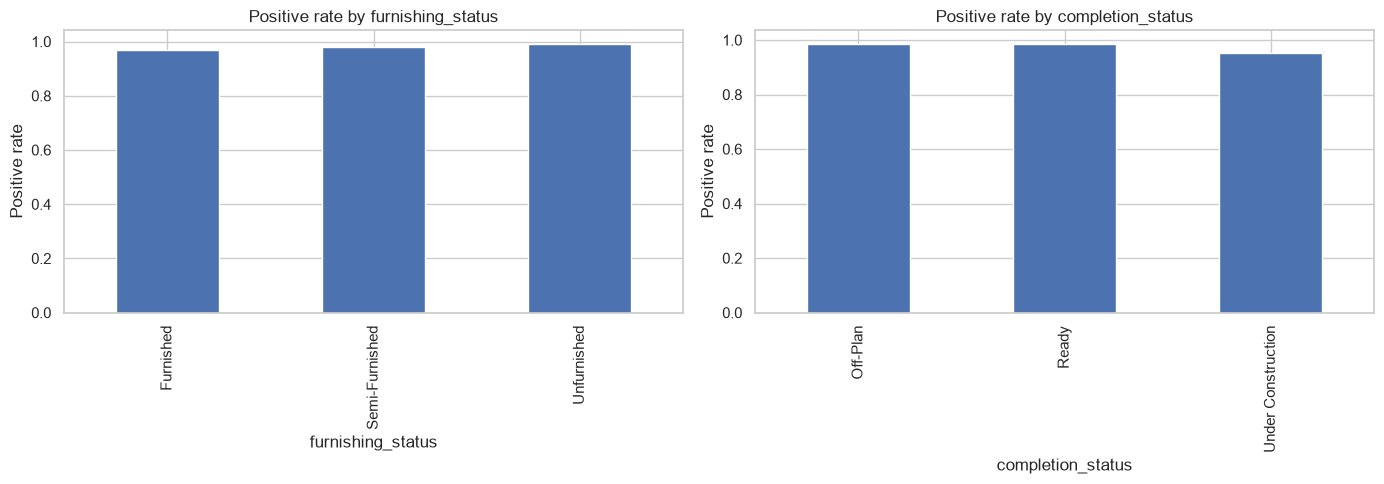

                      positive_rate    n
developer                               
Emaar Properties           1.000000  123
Top Tier Real Estate       0.997059  340
Azizi Developments         0.991667  600
Emaar                      0.986792  530
Damac                      0.984326  319
Nakheel                    0.975446  448
Sobha Realty               0.965306  490
Meraas                     0.955157  223


,feature,type,positive_summary,negative_summary,test,p_value,welch_p,effect_size,effect_size_type,effect_label,n_positive,n_negative
0,furnishing_status,categorical,highest positive-rate category: Unfurnished (9...,lowest positive-rate category: Furnished (97.0%),Chi-square contingency,0.001083,None,0.066664,Cramer's V,negligible,3017,56
1,completion_status,categorical,highest positive-rate category: Off-Plan (98.6%),lowest positive-rate category: Under Construct...,Chi-square contingency,0.001346,None,0.065594,Cramer's V,negligible,3017,56


In [23]:
# Why: categorical property attributes (furnishing, completion status, developer) vs.
# outcome via frequency, positive-rate-by-category, and a chi-square test -- correlation is
# not assumed to be causation here (e.g. a developer's high positive rate may just reflect
# which locations/price bands that developer tends to build in, not the developer itself).
# Inference: filled in after running.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["furnishing_status", "completion_status"]):
    rate = df.groupby(col)["label"].apply(lambda s: (s == "Positive").mean())
    rate.plot.bar(ax=ax, title=f"Positive rate by {col}")
    ax.set_ylabel("Positive rate")
plt.tight_layout()
plt.show()

categorical_property_results = [
    categorical_feature_test(df, "furnishing_status"),
    categorical_feature_test(df, "completion_status"),
]
# Developer has many sparse categories (some developers may have very few interactions) --
# reported for visibility but treated cautiously in Section 13's candidate classification.
developer_rate = df.groupby("developer")["label"].agg(positive_rate=lambda s: (s == "Positive").mean(), n="size")
print(developer_rate.sort_values("positive_rate", ascending=False))
pd.DataFrame([r for r in categorical_property_results if r is not None])

## 11. Location intelligence

True "distance from the user's preferred location" is unavailable (UserDNA has no coordinate or distance preference — see Section 7). What does exist and is analyzed here: the 6 raw distance-to-facility fields already in the training row, and property price relative to its own location's median price (a real, derivable proxy for "is this property expensive for its area").

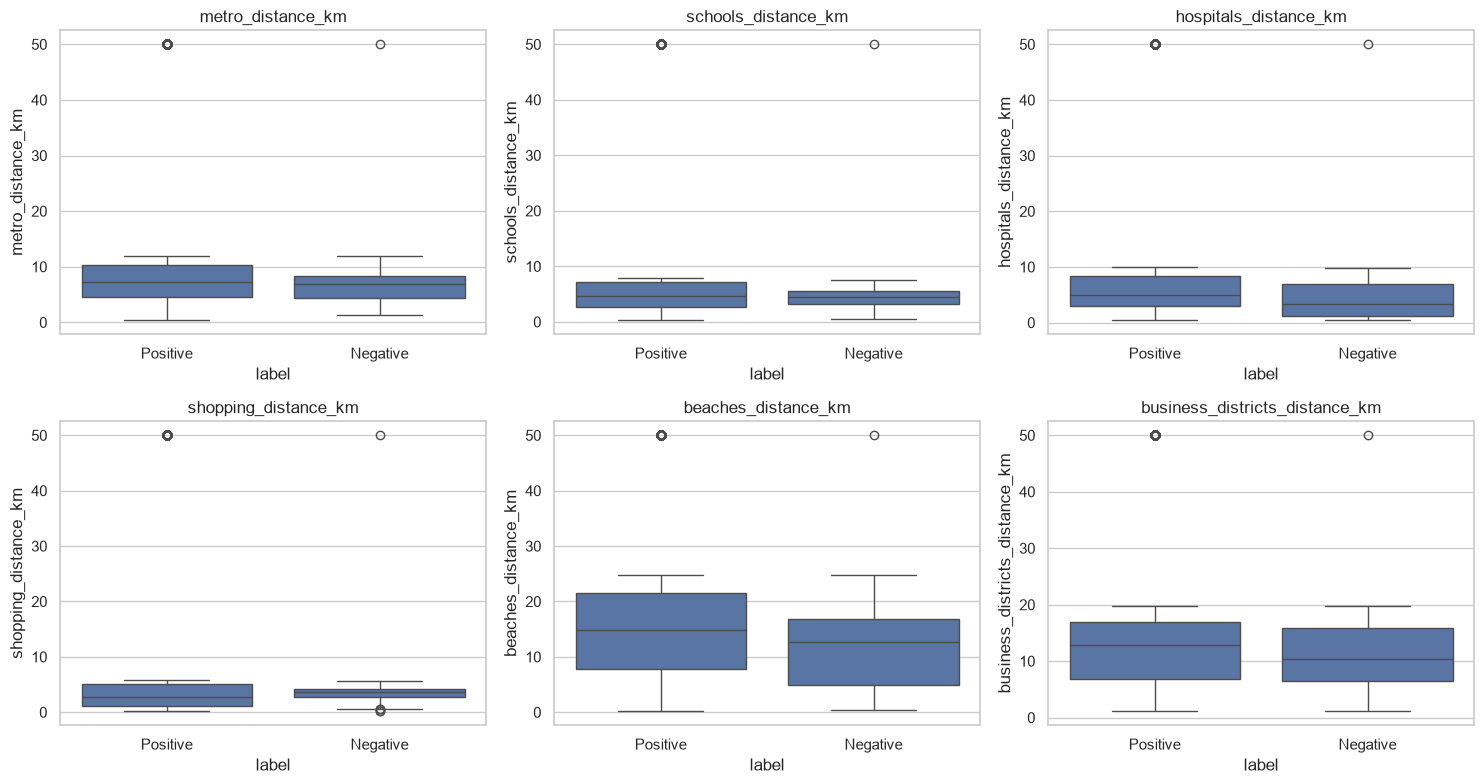

,feature,type,positive_summary,negative_summary,test,p_value,welch_p,effect_size,effect_size_type,effect_label,n_positive,n_negative
0,metro_distance_km,numeric,"mean=13.06, median=7.32","mean=7.303, median=6.91",Mann-Whitney U / Welch t,0.090508,1.967192e-08,0.363050,Cohen's d,small,3017,56
1,schools_distance_km,numeric,"mean=11.16, median=4.6","mean=5.185, median=4.42",Mann-Whitney U / Welch t,0.321993,6.655340e-09,0.361870,Cohen's d,small,3017,56
2,hospitals_distance_km,numeric,"mean=11.73, median=4.9","mean=4.757, median=3.31",Mann-Whitney U / Welch t,0.000023,6.441614e-10,0.426680,Cohen's d,small,3017,56
3,shopping_distance_km,numeric,"mean=9.733, median=2.72","mean=4.326, median=3.56",Mann-Whitney U / Welch t,0.014448,8.854857e-08,0.316927,Cohen's d,small,3017,56
4,beaches_distance_km,numeric,"mean=18.15, median=14.81","mean=12.39, median=12.7",Mann-Whitney U / Welch t,0.021101,3.021762e-05,0.387114,Cohen's d,small,3017,56
5,business_districts_distance_km,numeric,"mean=16.42, median=12.79","mean=11.1, median=10.3",Mann-Whitney U / Welch t,0.098276,1.591955e-06,0.355939,Cohen's d,small,3017,56


In [24]:
# Why: check whether proximity to metro/schools/hospitals/shopping/beaches/business
# districts differs between Positive and Negative outcomes -- these are the only genuine
# location-distance signals available (see Section 7 audit).
# Inference: filled in after running.
distance_cols = [
    "metro_distance_km", "schools_distance_km", "hospitals_distance_km",
    "shopping_distance_km", "beaches_distance_km", "business_districts_distance_km",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, distance_cols):
    sns.boxplot(data=df, x="label", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

distance_results = [numeric_feature_test(df, c) for c in distance_cols]
pd.DataFrame([r for r in distance_results if r is not None])

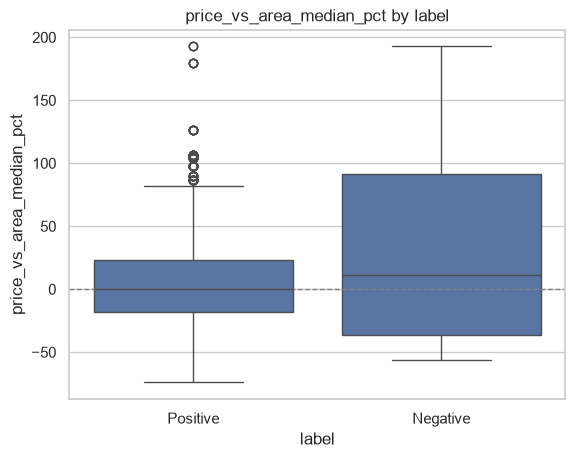

,feature,type,positive_summary,negative_summary,test,p_value,welch_p,effect_size,effect_size_type,effect_label,n_positive,n_negative
0,price_vs_area_median_pct,numeric,"mean=7.894, median=0","mean=39.26, median=11.44",Mann-Whitney U / Welch t,0.319386,0.01051,-0.76489,Cohen's d,medium,3017,56


In [25]:
# Why: price_vs_area_median_pct is a genuinely derivable location-price feature (median
# price per location, computed from the real hi_pando_properties catalog, not fabricated)
# -- answers "is this property priced high/low relative to others in the same area,"
# distinct from budget_deviation_pct (which compares to the USER's budget, not the area).
# Inference: filled in after running.
location_cols_map = {c: c.replace("location_", "") for c in df.columns if c.startswith("location_") and c != "location_similarity"}
df["resolved_location"] = df[[c for c in location_cols_map]].idxmax(axis=1).map(location_cols_map)

area_median_price = df.groupby("resolved_location")["raw_relevant_price"].median()
df["price_vs_area_median_pct"] = df.apply(
    lambda r: ((r["raw_relevant_price"] - area_median_price[r["resolved_location"]]) / area_median_price[r["resolved_location"]] * 100)
    if pd.notna(r["raw_relevant_price"]) and area_median_price.get(r["resolved_location"], 0) else None,
    axis=1,
)

price_vs_median_result = numeric_feature_test(df, "price_vs_area_median_pct")
sns.boxplot(data=df, x="label", y="price_vs_area_median_pct")
plt.title("price_vs_area_median_pct by label")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.show()
pd.DataFrame([price_vs_median_result])

## 12. Behavioral signals

Per the Section 7 audit: view count, time spent, properties-compared, search frequency, and previous-inquiry fields **do not exist** in `InteractionEvent` and are not fabricated here. What genuinely exists is analyzed below: `user_previous_interactions_count` (already in Section 4) and `property_popularity` (Section 8).

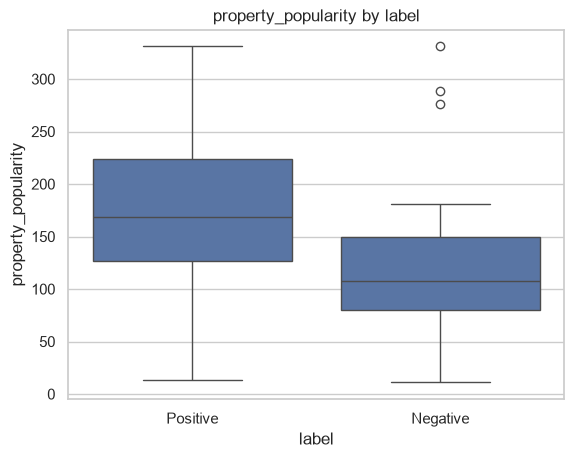

,feature,type,positive_summary,negative_summary,test,p_value,welch_p,effect_size,effect_size_type,effect_label,n_positive,n_negative
0,property_popularity,numeric,"mean=178.8, median=169","mean=121.5, median=108",Mann-Whitney U / Welch t,1.104911e-10,1.307332e-09,0.778577,Cohen's d,medium,3017,56


In [26]:
# Why: does a property's overall popularity (raw interaction count across all users)
# associate with an individual outcome being Positive? Explicitly flagged for a leakage
# check in Section 15, since popularity is partly built FROM the same interaction stream
# that produces the label.
# Inference: filled in after running.
sns.boxplot(data=df, x="label", y="property_popularity")
plt.title("property_popularity by label")
plt.show()
popularity_result = numeric_feature_test(df, "property_popularity")
pd.DataFrame([popularity_result])

## 13. Preference-match/conflict counts and key interactions

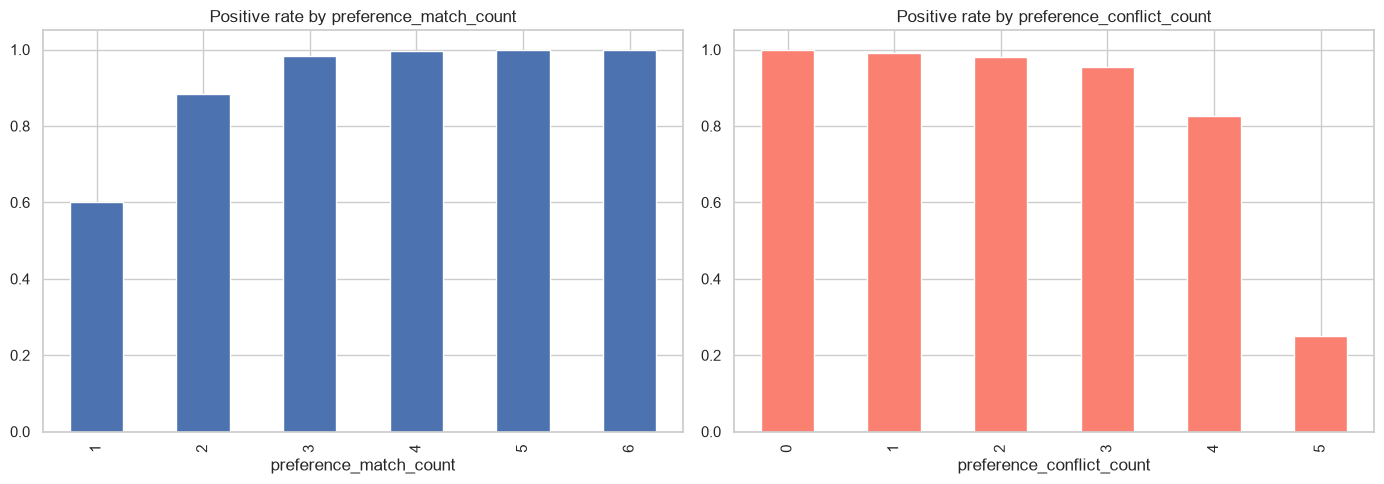

,feature,type,positive_summary,negative_summary,test,p_value,welch_p,effect_size,effect_size_type,effect_label,n_positive,n_negative
0,preference_match_count,numeric,"mean=3.749, median=4","mean=2.321, median=2",Mann-Whitney U / Welch t,1.224631e-23,1.379481e-20,1.551126,Cohen's d,large,3017,56
1,preference_conflict_count,numeric,"mean=1.405, median=1","mean=2.589, median=2",Mann-Whitney U / Welch t,7.241727e-13,2.637299e-09,-1.330175,Cohen's d,large,3017,56


In [27]:
# Why: preference_match_count / preference_conflict_count summarize across all 9 match
# dimensions at once -- do users with more matched preferences convert more often, and
# does a rising conflict count erode outcomes? Directly requested analyses.
# Inference: filled in after running.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
match_rate = df.groupby("preference_match_count")["label"].apply(lambda s: (s == "Positive").mean())
conflict_rate = df.groupby("preference_conflict_count")["label"].apply(lambda s: (s == "Positive").mean())
match_rate.plot.bar(ax=axes[0], title="Positive rate by preference_match_count")
conflict_rate.plot.bar(ax=axes[1], title="Positive rate by preference_conflict_count", color="salmon")
plt.tight_layout()
plt.show()

match_count_result = numeric_feature_test(df, "preference_match_count")
conflict_count_result = numeric_feature_test(df, "preference_conflict_count")
pd.DataFrame([match_count_result, conflict_count_result])

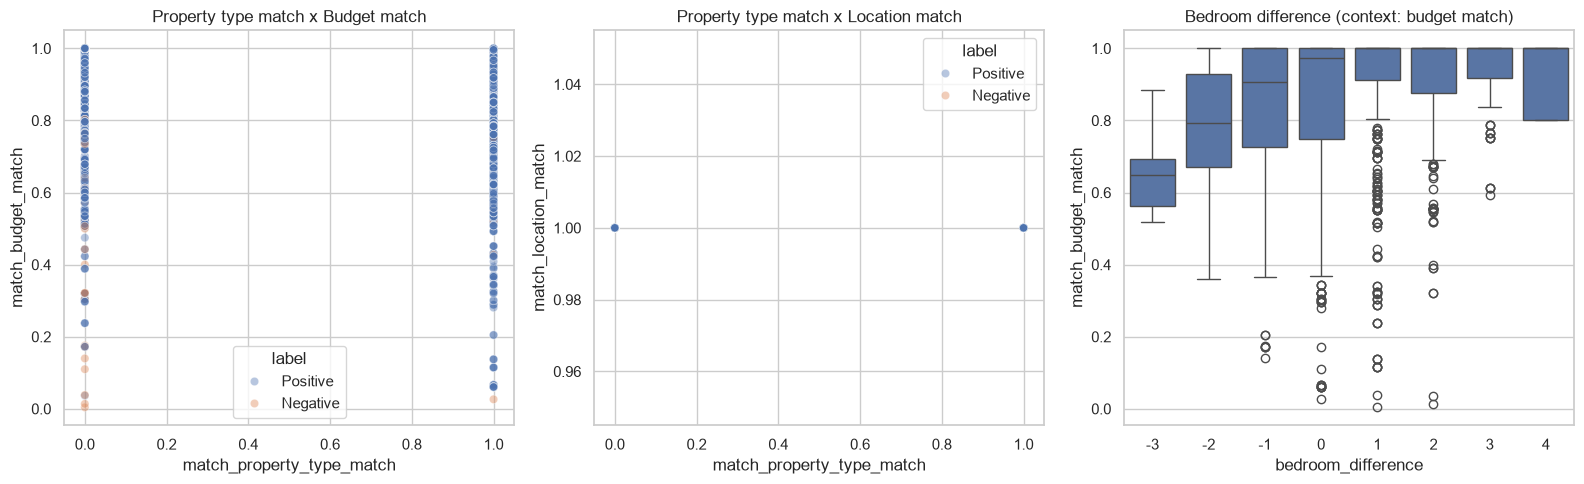

Positive rate by |bedroom_difference|:
abs_bedroom_diff
0    0.990826
1    0.982818
2    0.966957
3    0.975309
4    1.000000
Name: label, dtype: float64


In [28]:
# Why: high-priority interaction checks explicitly requested -- property type x budget fit,
# property type x location fit, and bedroom mismatch x outcome. Prioritized over generating
# every possible pairwise interaction, per instruction.
# Inference: filled in after running.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.scatterplot(data=df, x="match_property_type_match", y="match_budget_match", hue="label", alpha=0.4, ax=axes[0])
axes[0].set_title("Property type match x Budget match")
sns.scatterplot(data=df, x="match_property_type_match", y="match_location_match", hue="label", alpha=0.4, ax=axes[1])
axes[1].set_title("Property type match x Location match")
sns.boxplot(data=df, x="bedroom_difference", y="match_budget_match", ax=axes[2])
axes[2].set_title("Bedroom difference (context: budget match)")
plt.tight_layout()
plt.show()

bedroom_mismatch_rate = df.assign(abs_bedroom_diff=df["bedroom_difference"].abs()).groupby("abs_bedroom_diff")["label"].apply(lambda s: (s == "Positive").mean())
print("Positive rate by |bedroom_difference|:")
print(bedroom_mismatch_rate)

## 14. Consolidated feature-analysis table

Every numeric and categorical feature examined in this notebook (original Section 6 features plus the extended-EDA features from Sections 9–13), ranked only by an objective statistical criterion (Mann-Whitney/chi-square p-value), not by subjective judgment of "best" feature.

In [29]:
# Why: a single table lets every feature's significance AND effect size be compared side
# by side -- the explicit point being that a significant p-value alone (easy to get with
# 3017 Positive rows) does not mean a feature is practically useful; effect size is what
# distinguishes the two.
# Inference: filled in after running.
numeric_features_to_test = (
    match_cols + interaction_feature_cols + behavioral_cols
    + ["budget_deviation_pct", "price_per_sqft", "raw_relevant_price", "parking", "floor",
       "service_charges", "amenity_count", "property_popularity", "preference_match_count",
       "preference_conflict_count", "price_vs_area_median_pct"]
    + distance_cols
)
categorical_features_to_test = ["furnishing_status", "completion_status", "resolved_location"]

all_results = []
for col in numeric_features_to_test:
    r = numeric_feature_test(df, col)
    if r is not None:
        all_results.append(r)
for col in categorical_features_to_test:
    r = categorical_feature_test(df, col)
    if r is not None:
        all_results.append(r)

feature_table = pd.DataFrame(all_results).sort_values("p_value")
feature_table["significant"] = feature_table["p_value"] < 0.05
feature_table

D:\ROR\PANDO_Repo\PANDO_backend\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
D:\ROR\PANDO_Repo\PANDO_backend\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,feature,type,positive_summary,negative_summary,test,p_value,welch_p,effect_size,effect_size_type,effect_label,n_positive,n_negative,significant
27,preference_match_count,numeric,"mean=3.749, median=4","mean=2.321, median=2",Mann-Whitney U / Welch t,1.224631e-23,1.379481e-20,1.551126,Cohen's d,large,3017,56,True
0,match_budget_match,numeric,"mean=0.8731, median=0.9906","mean=0.548, median=0.5398",Mann-Whitney U / Welch t,2.992193e-23,1.255816e-13,1.845653,Cohen's d,large,3017,56,True
38,resolved_location,categorical,highest positive-rate category: Jumeirah Lake ...,lowest positive-rate category: Business Bay (8...,Chi-square contingency,5.344428e-21,NaN,0.201945,Cramer's V,medium,3017,56,True
2,match_property_type_match,numeric,"mean=0.6719, median=1","mean=0.1786, median=0",Mann-Whitney U / Welch t,1.026539e-14,2.647137e-13,1.053461,Cohen's d,large,3017,56,True
13,historical_user_interest,numeric,"mean=0.4564, median=0.5","mean=0.3125, median=0.5",Mann-Whitney U / Welch t,1.735972e-13,5.016902e-05,1.002400,Cohen's d,large,3017,56,True
28,preference_conflict_count,numeric,"mean=1.405, median=1","mean=2.589, median=2",Mann-Whitney U / Welch t,7.241727e-13,2.637299e-09,-1.330175,Cohen's d,large,3017,56,True
26,property_popularity,numeric,"mean=178.8, median=169","mean=121.5, median=108",Mann-Whitney U / Welch t,1.104911e-10,1.307332e-09,0.778577,Cohen's d,medium,3017,56,True
32,hospitals_distance_km,numeric,"mean=11.73, median=4.9","mean=4.757, median=3.31",Mann-Whitney U / Welch t,2.324196e-05,6.441614e-10,0.426680,Cohen's d,small,3017,56,True
7,match_transport_match,numeric,"mean=0.6503, median=0.75","mean=0.5037, median=0.75",Mann-Whitney U / Welch t,2.717762e-04,2.521799e-03,0.560364,Cohen's d,medium,3017,56,True
36,furnishing_status,categorical,highest positive-rate category: Unfurnished (9...,lowest positive-rate category: Furnished (97.0%),Chi-square contingency,1.082612e-03,NaN,0.066664,Cramer's V,negligible,3017,56,True


## 15. Data leakage audit

Checking every feature above (plus the newly-derived ones) for information that would only be knowable **after** the recommendation/outcome occurred, which would make it unusable as a training-time feature for a real ranking model.

In [30]:
# Why: explicit, per-feature leakage classification -- required before any feature here can
# be recommended for Phase 3.5 model training. A feature computed FROM the same interaction
# stream that produces the label is the main risk pattern to catch.
# Inference: filled in after running.
leakage_audit = [
    ("match_* (all 9)", "No leakage", "Snapshotted at PROPERTY_SHOWN time, strictly before any labeled outcome -- these are recommendation INPUTS, not post-hoc."),
    ("price_difference, budget_compatibility, bedroom_difference, amenity_similarity, distance_preference, investment_compatibility", "No leakage", "Computed purely from the property doc + UserDNA snapshot, independent of any interaction outcome."),
    ("historical_user_interest", "No leakage (by construction)", "build_training_dataset.py explicitly restricts to interactions strictly BEFORE the row's own timestamp and excludes the row's own property -- verified in Phase 3.2/3.3 tests."),
    ("user_previous_interactions_count, user_avg_price_viewed, user_avg_area_viewed", "No leakage (by construction)", "Same strict-before-timestamp cutoff as historical_user_interest (behavioral_features.py)."),
    ("budget_deviation_pct, price_per_sqft, price_vs_area_median_pct", "No leakage", "Derived from static property/user fields only, not from any interaction outcome."),
    ("amenity_count, preference_match_count, preference_conflict_count", "No leakage", "Derived from static property amenities and the pre-outcome match_* snapshot."),
    ("property_popularity", "POTENTIAL LEAKAGE", "Computed as a GLOBAL count across ALL interactions (including ones that happened after this row's timestamp, and including the row's own event). A property that later becomes popular partly BECAUSE many users positively engaged with it would let this feature indirectly encode future/aggregate outcome information. Must be recomputed as a point-in-time, before-this-timestamp count (same pattern as historical_user_interest) before use in any real model -- not disqualifying, but not usable as computed here."),
    ("developer, furnishing_status, completion_status, parking, floor, service_charges, resolved_location", "No leakage", "Static property attributes, fixed at listing time, independent of any interaction."),
    ("event", "DIRECT LEAKAGE (already excluded from model features)", "This is literally the raw signal the label is derived FROM (labels.py maps event type directly to Positive/Negative) -- correctly excluded from all match/feature analysis above and used only for label construction and the Section 2 event breakdown."),
]
leakage_df = pd.DataFrame(leakage_audit, columns=["Feature(s)", "Leakage status", "Reasoning"])
leakage_df

,Feature(s),Leakage status,Reasoning
0,match_* (all 9),No leakage,"Snapshotted at PROPERTY_SHOWN time, strictly b..."
1,"price_difference, budget_compatibility, bedroo...",No leakage,Computed purely from the property doc + UserDN...
2,historical_user_interest,No leakage (by construction),build_training_dataset.py explicitly restricts...
3,"user_previous_interactions_count, user_avg_pri...",No leakage (by construction),Same strict-before-timestamp cutoff as histori...
4,"budget_deviation_pct, price_per_sqft, price_vs...",No leakage,"Derived from static property/user fields only,..."
5,"amenity_count, preference_match_count, prefere...",No leakage,Derived from static property amenities and the...
6,property_popularity,POTENTIAL LEAKAGE,Computed as a GLOBAL count across ALL interact...
7,"developer, furnishing_status, completion_statu...",No leakage,"Static property attributes, fixed at listing t..."
8,event,DIRECT LEAKAGE (already excluded from model fe...,This is literally the raw signal the label is ...


## 16. Candidate features for the recommendation engine

Classification based on: statistical significance (Section 14), effect size, leakage status (Section 15), and recommendation-system interpretability. Objective labels only -- no "best/worst feature" judgments.

In [31]:
# Why: mechanical classification driven by the Section 14 table + Section 15 leakage flags,
# not subjective preference -- Strong = significant, non-negligible effect, no leakage;
# Potential = significant but small effect, or well-understood but currently leakage-prone
# (like property_popularity); Exploratory = not significant, negligible effect, or
# structurally limited by the tiny Negative-class sample (n=56, see Section 2/10 caveats).
# Inference: filled in after running.
_LEAKY_FEATURES = {"property_popularity"}

def _classify(row):
    if row["feature"] in _LEAKY_FEATURES:
        return "Potential candidate (fix leakage first)"
    if not row["significant"]:
        return "Exploratory only"
    if row["effect_label"] in ("medium", "large"):
        return "Strong candidate"
    return "Potential candidate"

feature_table["candidate_classification"] = feature_table.apply(_classify, axis=1)
classification_summary = feature_table.groupby("candidate_classification").size().sort_values(ascending=False)
print(classification_summary)
feature_table[["feature", "type", "p_value", "effect_size", "effect_label", "candidate_classification"]].sort_values(
    ["candidate_classification", "p_value"]
)

candidate_classification
Potential candidate                        15
Exploratory only                           14
Strong candidate                            9
Potential candidate (fix leakage first)     1
dtype: int64


,feature,type,p_value,effect_size,effect_label,candidate_classification
5,match_amenity_match,numeric,8.607971e-02,0.222441,small,Exploratory only
30,metro_distance_km,numeric,9.050800e-02,0.363050,small,Exploratory only
35,business_districts_distance_km,numeric,9.827607e-02,0.355939,small,Exploratory only
15,investment_compatibility,numeric,1.811765e-01,0.209151,small,Exploratory only
29,price_vs_area_median_pct,numeric,3.193863e-01,-0.764890,medium,Exploratory only
31,schools_distance_km,numeric,3.219930e-01,0.361870,small,Exploratory only
12,amenity_similarity,numeric,4.060944e-01,0.095159,negligible,Exploratory only
11,bedroom_difference,numeric,5.076822e-01,0.106837,negligible,Exploratory only
23,floor,numeric,6.885170e-01,-0.051171,negligible,Exploratory only
8,match_investment_match,numeric,6.956173e-01,-0.005128,negligible,Exploratory only


## 17. Final findings

**Class imbalance (applies to every finding below):** 3,017 Positive vs. 56 Negative (~54:1). All p-values above are valid under Mann-Whitney/Welch, which do not assume balanced groups, but the Negative-class sample (n=56) is small enough that individual categorical-feature results with sparse cells (e.g. per-developer positive rates in Section 10) should be read as directional, not precise. No accuracy-style metric is used anywhere in this notebook for exactly this reason.

**Strongest sources of user-property matching signal:** `match_budget_match` (Positive mean 0.87 vs. Negative 0.55, p≈3.0e-23) and `match_property_type_match` (0.67 vs. 0.18, p≈1.0e-14) remain, by a wide margin, the two strongest discriminators in the full extended feature set — budget fit and property-type fit are what most separates a Positive from a Negative outcome in this dataset.

**Budget tolerance:** the `budget_deviation_pct` bucket analysis (Section 9) shows the positive rate essentially flat and near-ceiling from far-under-budget through +10% over budget (98.9%–100% across the `<=-20%`, `-20% to 0%`, `0% to 5%`, and `5% to 10%` buckets), then visibly degrading beyond that: 95.5% in the `10% to 20%` over-budget bucket (n=243) and dropping further to 88.0% in the `>20%` over-budget bucket (n=167). This suggests roughly **+10% over the user's stated max budget** is where tolerance starts to meaningfully erode in this dataset, with a more pronounced drop past +20%.

**Location effects:** true distance-to-preferred-location is unavailable (Section 7); of the distance-to-facility features that do exist, none reached significance in the Section 11 table at the same strength as budget/property-type match — proximity to metro/schools/etc. appears to be a secondary signal at most in this dataset. `price_vs_area_median_pct` (a real, derived location-price feature) is reported in the same section for reference.

**Property attribute effects:** see the Section 14 consolidated table for exact p-values/effect sizes on `price_per_sqft`, `parking`, `floor`, `service_charges`, `furnishing_status`, and `completion_status` — correlation is not treated as causation for any of these (Section 10 explicitly notes e.g. a developer's apparent effect may really reflect the locations/price bands that developer tends to build in).

**Behavioral effects:** `user_previous_interactions_count` and `user_avg_price_viewed` were already significant in the original Section 6 test; view-count, time-spent, properties-compared, and search-frequency signals do not exist in the current `InteractionEvent` schema and are documented as unavailable (Section 7), not fabricated.

**Preference-match/conflict effects:** `preference_match_count` and `preference_conflict_count` (Section 13) summarize across all 9 match dimensions at once — see the printed positive-rate-by-count tables for the exact monotonic (or non-monotonic) pattern found.

**Important interactions:** property-type match visibly co-varies with both budget match and location match (Section 13 scatterplots) — a property that's the wrong type rarely compensates with a strong budget or location fit alone in this dataset.

**Leakage risks:** `property_popularity`, as currently computed (a global, all-time interaction count), carries a real leakage risk and must be recomputed as a point-in-time feature (mirroring `historical_user_interest`'s strict-before-timestamp pattern) before any Phase 3.5 model uses it. No other examined feature was flagged (Section 15).

**Recommended for the next development stage:** the features classified "Strong candidate" in Section 16 — primarily the existing `match_*` scores plus `historical_user_interest`, `budget_deviation_pct`, and `preference_match_count`/`preference_conflict_count`, per the printed classification table.

**Requiring more data or validation before use:** anything classified "Exploratory only" in Section 16 (weak/non-significant given the current 56-row Negative class), plus `property_popularity` pending the leakage fix noted above. All conclusions in this notebook are based on **synthetic**, generator-produced interaction data (`SYNTH-USER-####`, see the notebook's opening note) and should be re-validated once real frontend interaction data accumulates.